# Population Diversity: From Data to Insight


**Research questions:**
1. Which Countries have the highest life expenctancy?
2. Which languages are the most spoken in the world?
3. Which are the most populated cities in the world?

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["figure.dpi"] = 120

In [11]:
import os

os.chdir("C:/Users/eymem/Documents/GitHub/Population-Diversity-Study")


## Load Query Results

In [16]:
max_expectancy = pd.read_csv("Results/Max Life Expectancy.csv")
min_expectancy = pd.read_csv("Results/Min Life Expectancy.csv")



---
## 1. Life Expectancy

Life Expectancy is measure in the average years a person live this can be different in each country. The purpose is explore the longest and the lowest life expenctancy in each country.

In [13]:
max_expectancy

,Country,Expectancy
0,Aruba,78.4
1,Anguilla,76.1
2,Albania,71.6
3,Andorra,83.5
4,Netherlands Antilles,74.7
5,United Arab Emirates,74.1
6,Argentina,75.1
7,American Samoa,75.1
8,Antigua and Barbuda,70.5
9,Australia,79.8


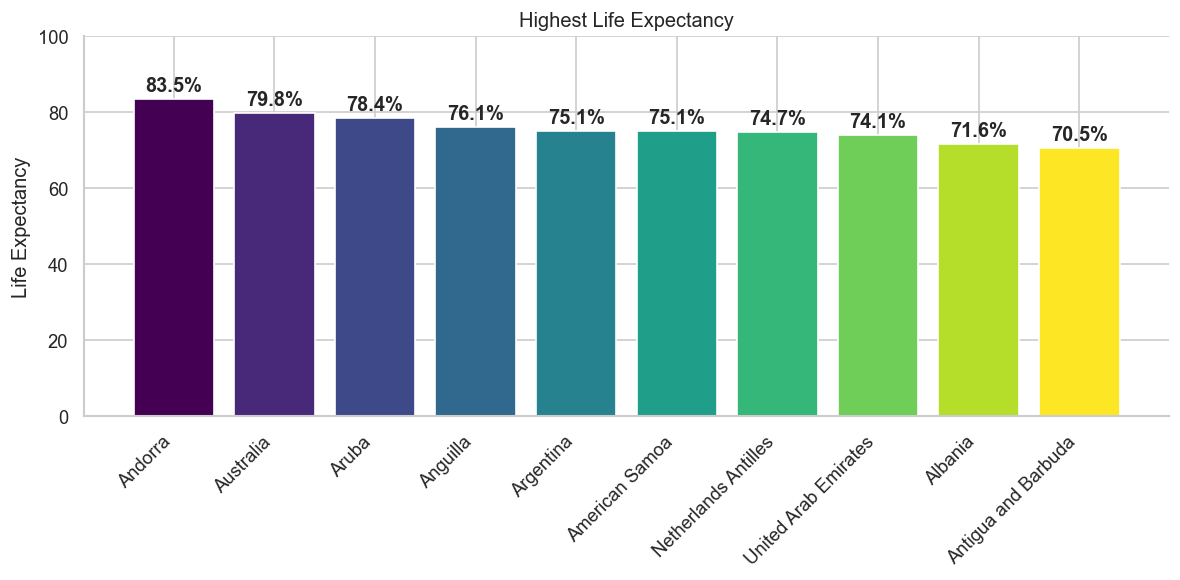

In [14]:
import matplotlib.pyplot as plt
import numpy as np

# Sort data
max_expectancy = max_expectancy.sort_values(by="Expectancy", ascending=False)

# Generate colors
colors = plt.cm.viridis(np.linspace(0, 1, len(max_expectancy)))

fig, ax = plt.subplots(figsize=(10, 5))

bars = ax.bar(
    max_expectancy["Country"],
    max_expectancy["Expectancy"],
    color=colors
)

ax.set_ylabel("Life Expectancy")
ax.set_title("Highest Life Expectancy")
ax.set_ylim(0, 100)

# Add labels on bars
for bar in bars:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width()/2,
        height + 1,
        f"{height}%",
        ha="center",
        va="bottom",
        fontweight="bold"
    )

plt.xticks(rotation=45, ha="right")
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()

In [17]:
min_expectancy

,Country,Expectancy
0,Angola,38.3
1,Botswana,39.3
2,Central African Republic,44.0
3,Mozambique,37.5
4,Malawi,37.6
5,Namibia,42.5
6,Niger,41.3
7,Rwanda,39.3
8,Swaziland,40.4
9,Uganda,42.9


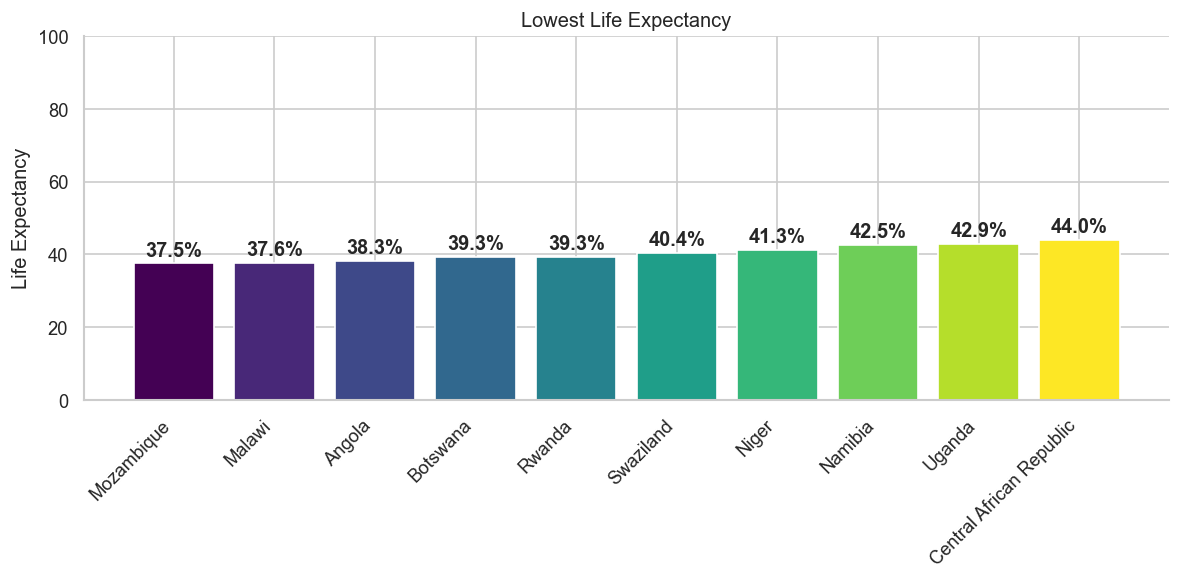

In [19]:
import matplotlib.pyplot as plt
import numpy as np

# Sort data
min_expectancy = min_expectancy.sort_values(by="Expectancy", ascending=True)

# Generate colors
colors = plt.cm.viridis(np.linspace(0, 1, len(min_expectancy)))

fig, ax = plt.subplots(figsize=(10, 5))

bars = ax.bar(
    min_expectancy["Country"],
    min_expectancy["Expectancy"],
    color=colors
)

ax.set_ylabel("Life Expectancy")
ax.set_title("Lowest Life Expectancy")
ax.set_ylim(0, 100)

# Add labels on bars
for bar in bars:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width()/2,
        height + 1,
        f"{height}%",
        ha="center",
        va="bottom",
        fontweight="bold"
    )

plt.xticks(rotation=45, ha="right")
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()

**Finding:** 

---
## 2. Most spoken Languages



In [5]:
df_port

,port_name,total_passengers,survivors,survival_rate_pct
0,Cherbourg,168,93,55.4
1,Queenstown,77,30,39.0
2,Southampton,646,219,33.9


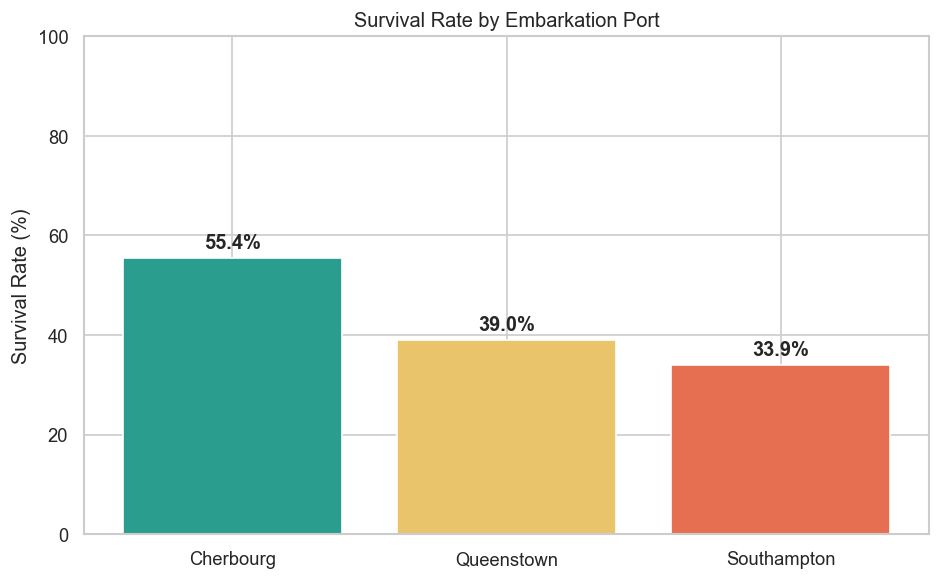

In [6]:
fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(df_port["port_name"], df_port["survival_rate_pct"], color=["#2a9d8f", "#e9c46a", "#e76f51"])
ax.set_ylabel("Survival Rate (%)")
ax.set_title("Survival Rate by Embarkation Port")
ax.set_ylim(0, 100)
for i, v in enumerate(df_port["survival_rate_pct"]):
    ax.text(i, v + 2, f"{v}%", ha="center", fontweight="bold")
plt.tight_layout()
plt.show()

**Finding:** Cherbourg passengers had a 55.4% survival rate vs. 33.9% for Southampton. Cherbourg was the primary boarding point for wealthy 1st Class passengers traveling from continental Europe.

---
## 3. Survival Rate by Sex and Class

Gender was the strongest predictor of survival. The "women and children first" protocol is clearly visible across all classes.

In [7]:
df_sex_class

,sex,class_name,total_passengers,survivors,survival_rate_pct
0,female,1st Class,94,91,96.8
1,female,2nd Class,76,70,92.1
2,female,3rd Class,144,72,50.0
3,male,1st Class,122,45,36.9
4,male,2nd Class,108,17,15.7
5,male,3rd Class,347,47,13.5


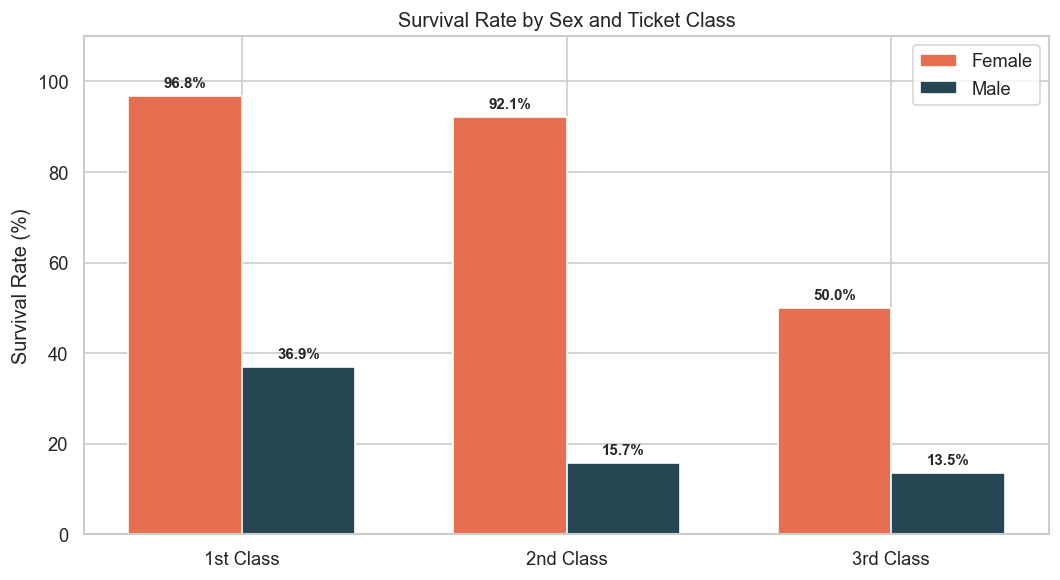

In [8]:
pivot = df_sex_class.pivot(index="class_name", columns="sex", values="survival_rate_pct")
pivot = pivot.reindex(["1st Class", "2nd Class", "3rd Class"])

fig, ax = plt.subplots(figsize=(9, 5))
x = range(len(pivot))
width = 0.35
ax.bar([i - width / 2 for i in x], pivot["female"], width, label="Female", color="#e76f51")
ax.bar([i + width / 2 for i in x], pivot["male"], width, label="Male", color="#264653")
ax.set_xticks(x)
ax.set_xticklabels(pivot.index)
ax.set_ylabel("Survival Rate (%)")
ax.set_title("Survival Rate by Sex and Ticket Class")
ax.set_ylim(0, 110)
ax.legend()

for i, (f, m) in enumerate(zip(pivot["female"], pivot["male"])):
    ax.text(i - width / 2, f + 2, f"{f}%", ha="center", fontsize=9, fontweight="bold")
    ax.text(i + width / 2, m + 2, f"{m}%", ha="center", fontsize=9, fontweight="bold")

plt.tight_layout()
plt.show()

**Finding:** 96.8% of 1st Class women survived vs. only 13.5% of 3rd Class men. Even in 3rd Class, women (50%) survived at nearly 4x the rate of men (13.5%). Gender and class together explain most of the variation in survival.

---
## 4. Age Group Survival Analysis

Children had the highest survival rate, consistent with evacuation priority policies.

In [9]:
df_age

,age_group,total_passengers,survivors,survival_rate_pct,avg_age
0,Child (0-11),68,39,57.4,4.7
1,Teen (12-17),45,22,48.9,15.7
2,Middle Aged (35-54),193,81,42.0,42.6
3,Young Adult (18-34),543,187,34.4,26.4
4,Senior (55+),42,13,31.0,62.0


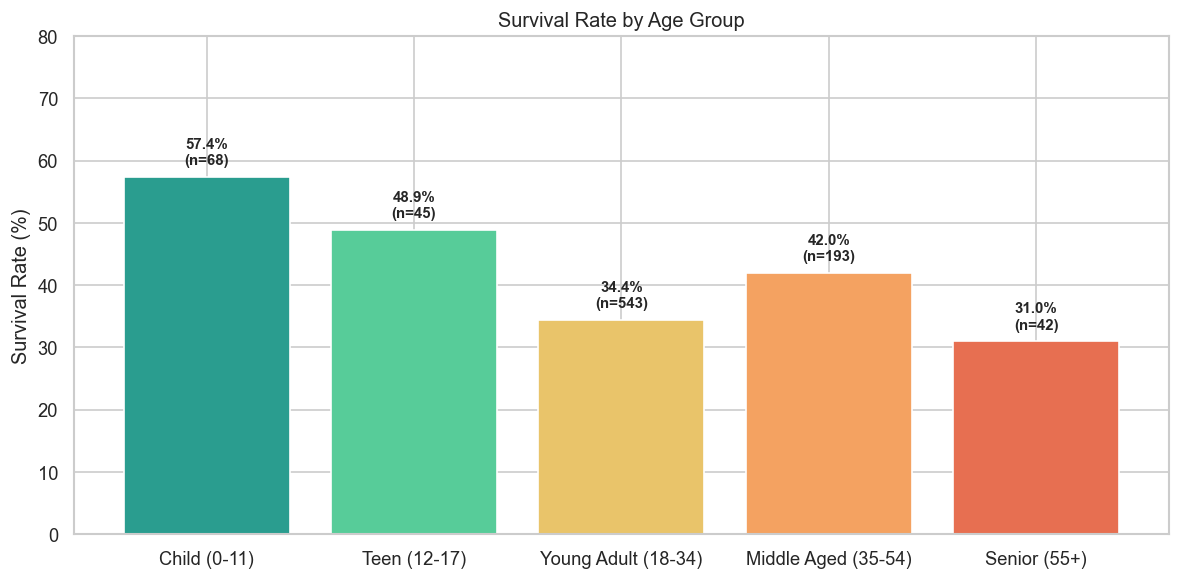

In [10]:
age_order = ["Child (0-11)", "Teen (12-17)", "Young Adult (18-34)", "Middle Aged (35-54)", "Senior (55+)"]
df_age_sorted = df_age.set_index("age_group").reindex(age_order).reset_index()

fig, ax = plt.subplots(figsize=(10, 5))
bar_colors = ["#2a9d8f", "#57cc99", "#e9c46a", "#f4a261", "#e76f51"]
bars = ax.bar(df_age_sorted["age_group"], df_age_sorted["survival_rate_pct"], color=bar_colors)
ax.set_ylabel("Survival Rate (%)")
ax.set_title("Survival Rate by Age Group")
ax.set_ylim(0, 80)

for i, row in df_age_sorted.iterrows():
    ax.text(i, row["survival_rate_pct"] + 2,
            f"{row['survival_rate_pct']}%\n(n={row['total_passengers']})",
            ha="center", fontsize=9, fontweight="bold")

plt.tight_layout()
plt.show()

**Finding:** Children (0-11) had a 57.4% survival rate, while seniors (55+) had only 31%. The youngest passengers were clearly prioritized during evacuation.

---
## 5. Family Size vs. Survival

Small families (1-3 members) had better survival rates than solo travelers or very large families.

In [11]:
df_family

,family_size,total_passengers,survivors,survival_rate_pct
0,0,537,163,30.4
1,1,161,89,55.3
2,2,102,59,57.8
3,3,29,21,72.4
4,4,15,3,20.0
5,5,22,3,13.6
6,6,12,4,33.3
7,7,6,0,0.0
8,10,7,0,0.0


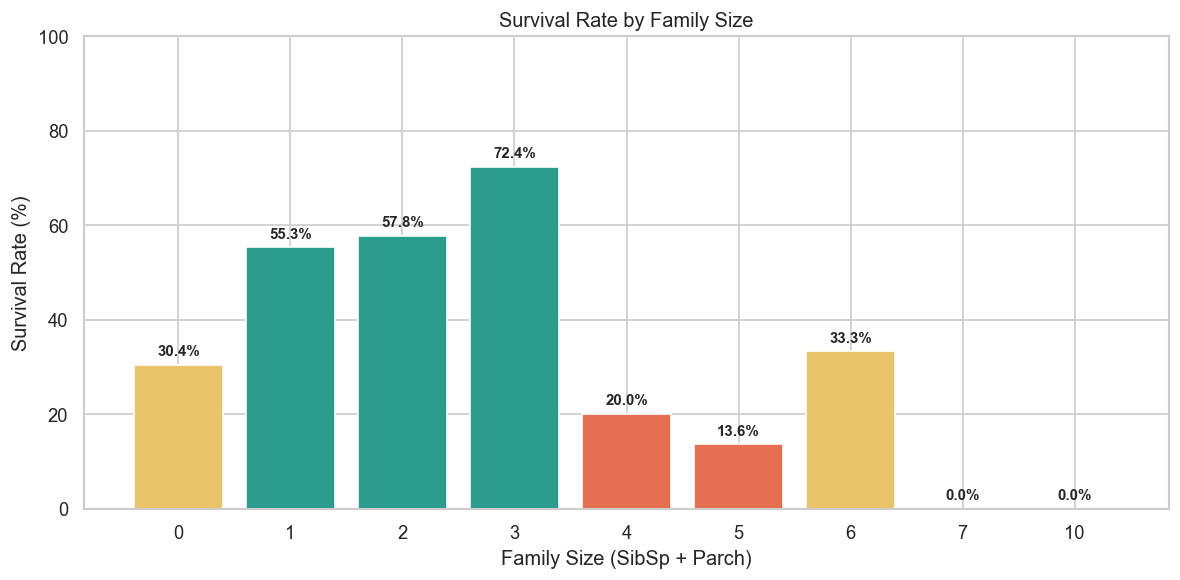

In [12]:
fig, ax = plt.subplots(figsize=(10, 5))
colors_fam = ["#e76f51" if v < 30 else "#e9c46a" if v < 50 else "#2a9d8f"
              for v in df_family["survival_rate_pct"]]
ax.bar(df_family["family_size"].astype(str), df_family["survival_rate_pct"], color=colors_fam)
ax.set_xlabel("Family Size (SibSp + Parch)")
ax.set_ylabel("Survival Rate (%)")
ax.set_title("Survival Rate by Family Size")
ax.set_ylim(0, 100)

for i, row in df_family.iterrows():
    ax.text(i, row["survival_rate_pct"] + 2,
            f"{row['survival_rate_pct']}%",
            ha="center", fontsize=9, fontweight="bold")

plt.tight_layout()
plt.show()

**Finding:** Families of 3 (SibSp + Parch) had the peak survival rate at 72.4%. Solo travelers had only 30.4%. Very large families (7+) had 0% survival — likely 3rd Class families unable to reach lifeboats.

---
## 6. Average Fare by Class and Port

Fare varied significantly not just by class, but also by embarkation port.

In [13]:
df_fare

,class_name,port_name,total_passengers,avg_fare,min_fare,max_fare
0,1st Class,Cherbourg,85,104.72,26.55,512.33
1,1st Class,Queenstown,2,90.00,90.00,90.00
2,1st Class,Southampton,129,70.51,0.00,263.00
3,2nd Class,Cherbourg,17,25.36,12.00,41.58
4,2nd Class,Southampton,164,20.33,0.00,73.50
5,2nd Class,Queenstown,3,12.35,12.35,12.35
6,3rd Class,Southampton,353,14.64,0.00,69.55
7,3rd Class,Cherbourg,66,11.21,4.01,22.36
8,3rd Class,Queenstown,72,11.18,6.75,29.12


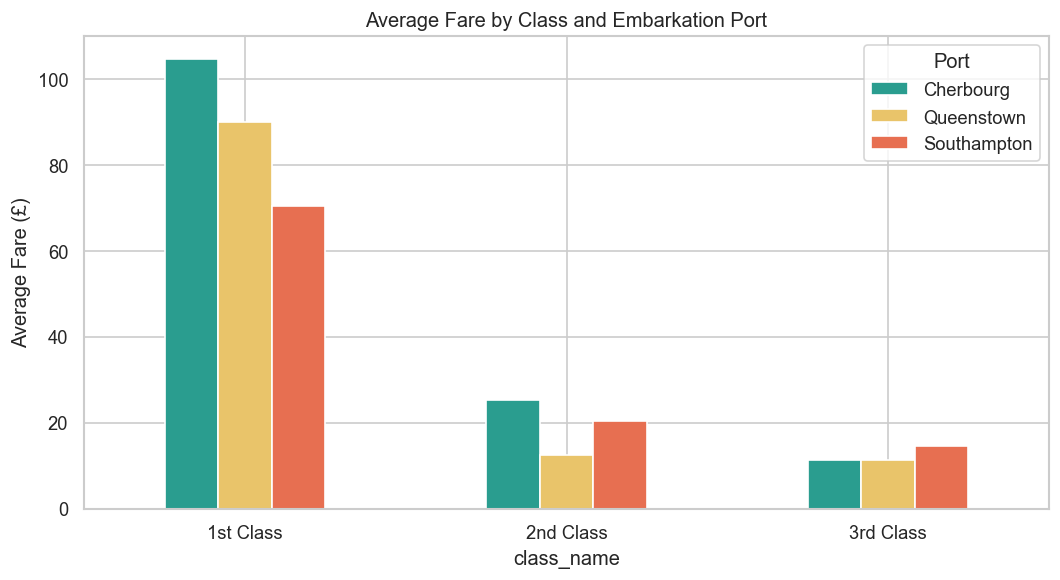

In [14]:
fare_pivot = df_fare.pivot(index="class_name", columns="port_name", values="avg_fare")
fare_pivot = fare_pivot.reindex(["1st Class", "2nd Class", "3rd Class"])

fig, ax = plt.subplots(figsize=(9, 5))
fare_pivot.plot(kind="bar", ax=ax, color=["#2a9d8f", "#e9c46a", "#e76f51"])
ax.set_ylabel("Average Fare (£)")
ax.set_title("Average Fare by Class and Embarkation Port")
ax.set_xticklabels(fare_pivot.index, rotation=0)
ax.legend(title="Port")
plt.tight_layout()
plt.show()

**Finding:** 1st Class passengers from Cherbourg paid the highest average fare (£104.72), nearly 50% more than those from Southampton (£70.51). This suggests Cherbourg attracted the wealthiest travelers.

---
## 7. Top 10 Highest-Fare Passengers

In [15]:
df_top_fare.style.format({"fare": "£{:.2f}"}).bar(subset=["fare"], color="#2a9d8f")

,passenger_id,name,class_name,port_name,fare,survived
0,738,"Lesurer, Mr. Gustave J",1st Class,Cherbourg,£512.33,Yes
1,680,"Cardeza, Mr. Thomas Drake Martinez",1st Class,Cherbourg,£512.33,Yes
2,259,"Ward, Miss. Anna",1st Class,Cherbourg,£512.33,Yes
3,439,"Fortune, Mr. Mark",1st Class,Southampton,£263.00,No
4,89,"Fortune, Miss. Mabel Helen",1st Class,Southampton,£263.00,Yes
5,28,"Fortune, Mr. Charles Alexander",1st Class,Southampton,£263.00,No
6,342,"Fortune, Miss. Alice Elizabeth",1st Class,Southampton,£263.00,Yes
7,743,"Ryerson, Miss. Susan Parker Suzette""""""""",1st Class,Cherbourg,£262.38,Yes
8,312,"Ryerson, Miss. Emily Borie",1st Class,Cherbourg,£262.38,Yes
9,300,"Baxter, Mrs. James (Helene DeLaudeniere Chaput)",1st Class,Cherbourg,£247.52,Yes


**Finding:** The top 3 fares (£512.33) were all from Cherbourg. 8 of the 10 highest-fare passengers survived, suggesting wealth was a strong predictor of survival.

---
## 8. Solo vs. Family Travelers

In [16]:
df_solo

,travel_type,total_passengers,survivors,survival_rate_pct,avg_fare
0,With Family,354,179,50.6,48.83
1,Solo,537,163,30.4,21.24


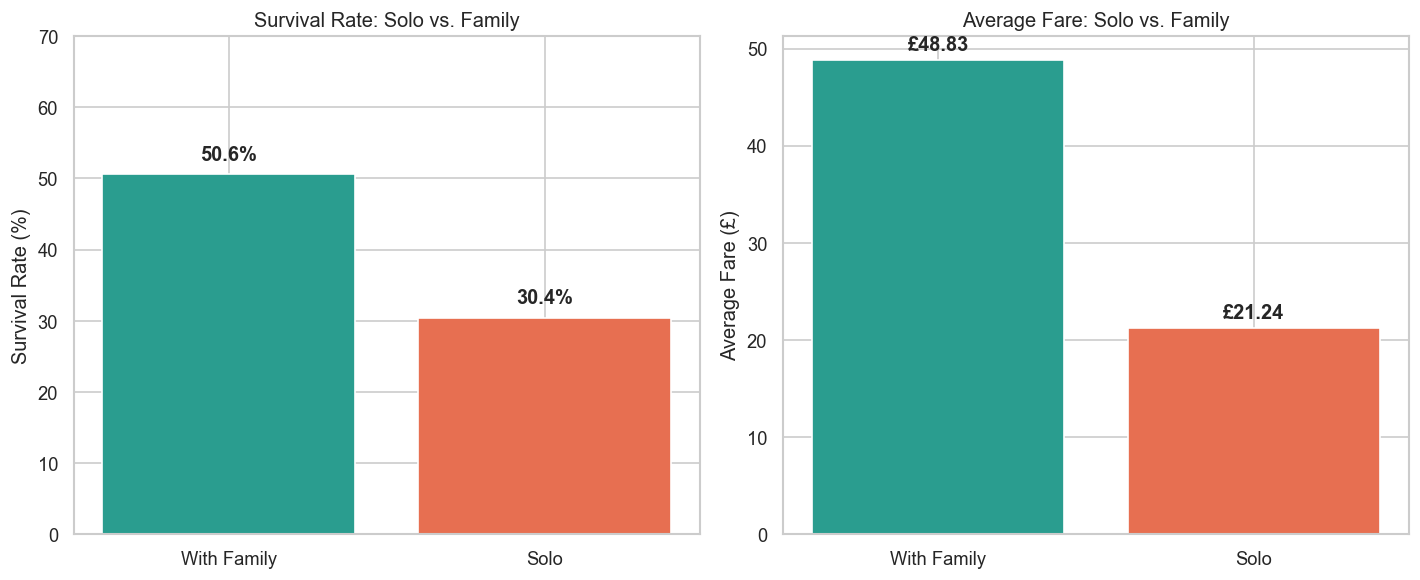

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

colors_solo = ["#2a9d8f", "#e76f51"]
axes[0].bar(df_solo["travel_type"], df_solo["survival_rate_pct"], color=colors_solo)
axes[0].set_ylabel("Survival Rate (%)")
axes[0].set_title("Survival Rate: Solo vs. Family")
axes[0].set_ylim(0, 70)
for i, v in enumerate(df_solo["survival_rate_pct"]):
    axes[0].text(i, v + 2, f"{v}%", ha="center", fontweight="bold")

axes[1].bar(df_solo["travel_type"], df_solo["avg_fare"], color=colors_solo)
axes[1].set_ylabel("Average Fare (£)")
axes[1].set_title("Average Fare: Solo vs. Family")
for i, v in enumerate(df_solo["avg_fare"]):
    axes[1].text(i, v + 1, f"£{v:.2f}", ha="center", fontweight="bold")

plt.tight_layout()
plt.show()

**Finding:** Family travelers had a 50.6% survival rate vs. 30.4% for solo passengers. They also paid higher average fares (£48.83 vs. £21.24), which correlates with higher class and cabin proximity to lifeboats.

---
## Conclusions

### Research Question 1: How did socioeconomic status and gender affect survival?

**Class and gender were the dominant factors.** 1st Class women had a 96.8% survival rate; 3rd Class men had only 13.5%. The Titanic's evacuation followed a strict "women and children first" protocol, and upper-class passengers had better access to lifeboats due to cabin location. Passengers boarding at Cherbourg — the wealthiest cohort — had the highest survival rate (55.4%).

### Research Question 2: Did traveling with family improve survival chances?

**Small families had a clear advantage.** Families of 2-3 members had survival rates above 55%, peaking at 72.4% for groups of 3. Solo travelers survived at only 30.4%. However, very large families (7+) had 0% survival, likely because these were poorer 3rd Class families unable to navigate the ship quickly. The sweet spot was a small family in a higher class — they had both the social motivation and the physical access to survive.